# Hospital Data Analysis Project

### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [3]:
df = pd.read_csv("healthcare_dataset.csv")

In [4]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,Bobby Jackson,19,Female,AB+,Infections,31-01-24,Matthew Smith,Northwestern Memorial Hospital,Blue Cross,2212.272701,328,Emergency,07-02-24,Azithromycin,Normal,7
1,Leslie Terry,15,Female,B-,Flu,20-08-19,Samantha Davies,UI Health (University of Illinois Hospital),UnitedHealthcare,3185.161388,265,Emergency,22-08-19,Tamiflu,Abnormal,2
2,Danny Smith,50,Female,A+,Cancer,22-09-22,Tiffany Mitchell,UI Health (University of Illinois Hospital),Blue Cross,72055.214060,205,Elective,30-10-22,Cisplatin,Inconclusive,38
3,Andrew Watts,24,Female,O+,Asthma,18-11-20,Kevin Wells,UI Health (University of Illinois Hospital),Aetna,4092.601229,450,Elective,19-11-20,Prednisone,Normal,1
4,Adrienne Bell,80,Female,A+,Heart Disease,19-09-22,Kathleen Hanna,Northwestern Memorial Hospital,Cigna,47985.660250,458,Routine,27-10-22,Beta-blockers,Inconclusive,38


### Data Understanding

In [5]:
df.shape

(55500, 16)

In [6]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results', 'Length of Stay'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
 15  Length of Stay      55500 non-null  int64  
dtypes: f

In [8]:
df.describe()

,Age,Billing Amount,Room Number,Length of Stay
count,55500.000000,55500.000000,55500.000000,55500.000000
mean,48.001622,21835.044636,301.134829,17.841009
std,21.105827,23574.413594,115.243069,20.272294
min,5.000000,500.220989,101.000000,1.000000
25%,32.000000,4195.525741,202.000000,4.000000
50%,50.000000,11089.537760,302.000000,8.000000
75%,65.000000,35887.703407,401.000000,28.000000
max,90.000000,99997.797980,500.000000,89.000000


In [9]:
df.nunique()

Name                  40235
Age                      86
Gender                    2
Blood Type                8
Medical Condition         8
Date of Admission      1827
Doctor                40341
Hospital                  4
Insurance Provider        5
Billing Amount        55500
Room Number             400
Admission Type            4
Discharge Date         1901
Medication               23
Test Results              3
Length of Stay           89
dtype: int64

### Data Cleaning

In [10]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
Length of Stay        0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.dtypes

Name                   object
Age                     int64
Gender                 object
Blood Type             object
Medical Condition      object
Date of Admission      object
Doctor                 object
Hospital               object
Insurance Provider     object
Billing Amount        float64
Room Number             int64
Admission Type         object
Discharge Date         object
Medication             object
Test Results           object
Length of Stay          int64
dtype: object

In [13]:
df[df['Age'] <= 0]  

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay


In [14]:
df[df['Billing Amount'] <= 0]

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay


In [15]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [16]:
df['Admission Type'].unique()

array(['Emergency', 'Elective', 'Routine', 'Urgent'], dtype=object)

In [17]:
df = pd.read_csv("healthcare_dataset.csv")

In [18]:
df['Date of Admission'] = pd.to_datetime(
    df['Date of Admission'],
    format='%d-%m-%y'
)

df['Discharge Date'] = pd.to_datetime(
    df['Discharge Date'],
    format='%d-%m-%y'
)

In [19]:
df[['Date of Admission', 'Discharge Date']].head(10)

,Date of Admission,Discharge Date
0,2024-01-31,2024-02-07
1,2019-08-20,2019-08-22
2,2022-09-22,2022-10-30
3,2020-11-18,2020-11-19
4,2022-09-19,2022-10-27
5,2023-12-20,2024-03-18
6,2020-11-03,2020-11-05
7,2021-12-28,2021-12-31
8,2020-07-01,2020-08-02
9,2021-05-23,2021-07-11


In [20]:
invalid_dates = df[
    df['Discharge Date'] < df['Date of Admission']
]

print("Invalid date records:", len(invalid_dates))

Invalid date records: 0


### Feature Engineering

In [21]:
bins = [0, 18, 30, 45, 60, 100]

labels = [
    '0-17',
    '18-29',
    '30-44',
    '45-59',
    '60+'
]

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    right=False
)

In [22]:
def get_generation(age):
    if age <= 12:
        return 'Gen Alpha'
    elif age <= 28:
        return 'Gen Z'
    elif age <= 44:
        return 'Millennials'
    elif age <= 60:
        return 'Gen X'
    elif age <= 78:
        return 'Baby Boomers'
    else:
        return 'Silent Generation'

df['Generation'] = df['Age'].apply(get_generation)

In [ ]:
df[['Age', 'Age Group', 'Generation']].head(10)

In [25]:
bins = [0, 5000, 10000, 20000, float('inf')]

labels = [
    'Low',
    'Medium',
    'High',
    'Very High'
]

df['Billing Category'] = pd.cut(
    df['Billing Amount'],
    bins=bins,
    labels=labels
)

In [26]:
df[['Billing Amount', 'Billing Category']].head(10) 

,Billing Amount,Billing Category
0,2212.272701,Low
1,3185.161388,Low
2,72055.214060,Very High
3,4092.601229,Low
4,47985.660250,Very High
5,37140.366420,Very High
6,557.697323,Low
7,4180.642896,Low
8,31688.559770,Very High
9,52910.753720,Very High


### EDA Questions

#### How many patients are in the dataset?

In [27]:
total_patients = df['Name'].count()
print("Total Patients:", total_patients)

Total Patients: 55500


#### What is the average age of the patients?

In [28]:
average_age = df['Age'].mean()
print("Average Age:", round(average_age, 2))

Average Age: 48.0


#### Which age group has the highest number of patients?

Age Group
60+      18841
45-59    13038
30-44    11508
18-29     6361
0-17      5752
Name: count, dtype: int64


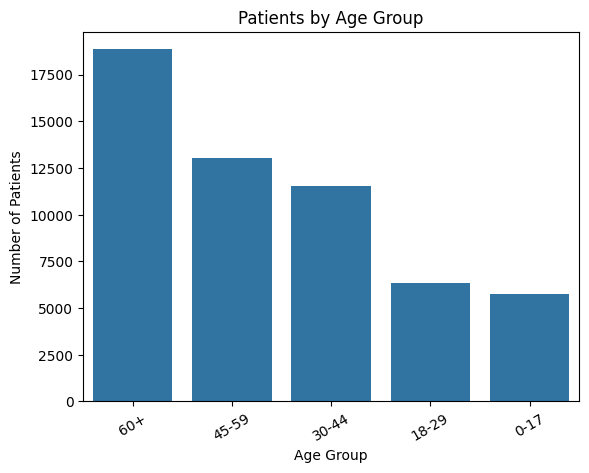

In [30]:
age_group_count = df['Age Group'].value_counts()
print(age_group_count)


sns.countplot(
    data=df,
    x='Age Group',
    order=df['Age Group'].value_counts().index
)

plt.title('Patients by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=30)
plt.show()


#### How are patients distributed across generations?

Generation
Gen X                14214
Baby Boomers         14144
Millennials          12052
Gen Z                 8516
Silent Generation     3521
Gen Alpha             3053
Name: count, dtype: int64


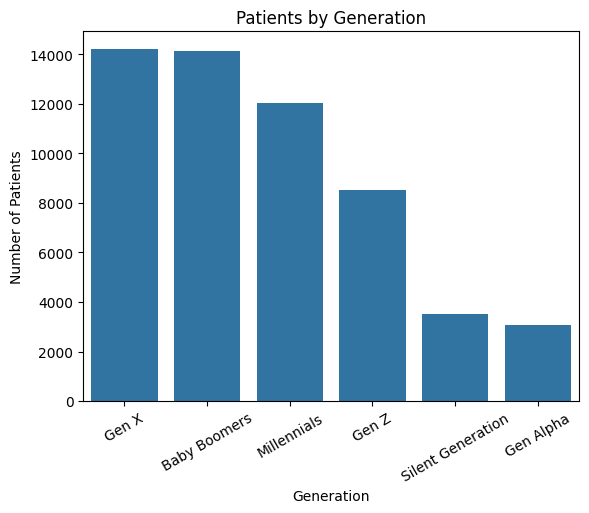

In [32]:
generation_count = df['Generation'].value_counts()
print(generation_count)

sns.countplot(
    data=df,
    x='Generation',
    order=df['Generation'].value_counts().index
)

plt.title('Patients by Generation')
plt.xlabel('Generation')
plt.ylabel('Number of Patients')
plt.xticks(rotation=30)
plt.show()

#### What is the distribution of patients by gender?

In [33]:
gender_count = df['Gender'].value_counts()
print(gender_count)

Gender
Female    27955
Male      27545
Name: count, dtype: int64


#### Which medical conditions are most common?

In [34]:
condition_count = df['Medical Condition'].value_counts()
print(condition_count)

Medical Condition
Flu              7046
Diabetes         7005
Obesity          6994
Cancer           6940
Asthma           6908
Heart Disease    6900
Alzheimer’s      6861
Infections       6846
Name: count, dtype: int64


#### Which admission type is most common?

In [35]:
admission_count = df['Admission Type'].value_counts()
print(admission_count)

Admission Type
Emergency    20104
Elective     13280
Urgent       11816
Routine      10300
Name: count, dtype: int64


#### Which medical condition has the highest average billing amount?

In [36]:
avg_billing = (
    df.groupby('Medical Condition')['Billing Amount']
    .mean()
    .sort_values(ascending=False)
)

print(avg_billing)

Medical Condition
Cancer           64537.088667
Heart Disease    44913.427049
Alzheimer’s      32543.542291
Diabetes         12503.188470
Obesity          10055.563055
Asthma            5025.348290
Infections        2747.567493
Flu               2744.152050
Name: Billing Amount, dtype: float64


#### Which medical condition has the longest average hospital stay?

Medical Condition
Alzheimer’s      54.417286
Cancer           36.543804
Heart Disease    26.860580
Diabetes          8.063098
Obesity           5.966400
Infections        5.521911
Asthma            3.503619
Flu               2.504967
Name: Length of Stay, dtype: float64


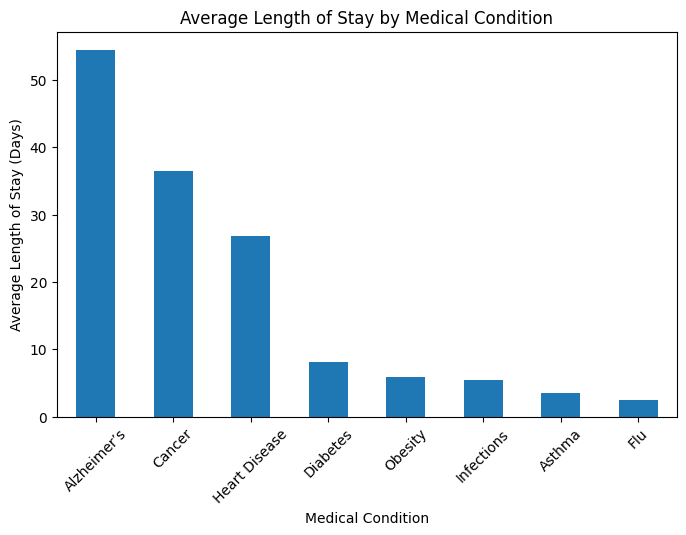

In [38]:
avg_stay = (
    df.groupby('Medical Condition')['Length of Stay']
    .mean()
    .sort_values(ascending=False)
)

print(avg_stay)



avg_stay.plot(kind='bar', figsize=(8, 5))

plt.title('Average Length of Stay by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Average Length of Stay (Days)')
plt.xticks(rotation=45)
plt.show()

#### How do hospital admissions change over time?

In [41]:
monthly_admissions = (
    df.groupby(
        df['Date of Admission'].dt.to_period('M')
    )
    .size()
)

print(monthly_admissions)

Date of Admission
2019-05     686
2019-06     907
2019-07     957
2019-08    1001
2019-09     936
           ... 
2024-01     909
2024-02     880
2024-03     906
2024-04     946
2024-05     213
Freq: M, Length: 61, dtype: int64


In [42]:
df.columns


Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results', 'Length of Stay', 'Age Group',
       'Generation', 'Billing Category'],
      dtype='object')

In [43]:
df.to_csv('hospital_cleaned.csv', index=False)